# Model Set 2: Ansys Surrogate (Qiskit Metal → Capacitance)

This notebook trains a model that learns the **Qiskit Metal parameters → Capacitance / H-params** mapping.

It is the "flipped" version of Model Set 1. Instead of predicting design parameters from physics,
it predicts physics (capacitance matrix values) from design parameters.

**Purpose:** This model will later serve as a fast Ansys surrogate inside the Model 1 training loop,
so the loss function can be based on *physics outputs* rather than parameter matching.

**Key simplification:** Since all outputs (capacitance values) are continuous, we do NOT need:
- Two output heads
- One-hot / linear encoding branching
- Finger count classification

This is a pure regression problem with a single output head.

## Configuration

In [1]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters import *

## Library

In [2]:
import os, gc, joblib, json, time

# Disable some console warnings so you can be free of them printing. 
# Comment the next two lines if you are a professional and like looking at warnings.
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf 
tf.keras.backend.set_floatx("float32")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from keras_tuner import HyperModel, RandomSearch
from pathlib import Path

import numpy as np
import pandas as pd

In [3]:
seed = 0

# Input seed value. If this value is the same, the random number generator 
# will generate the same set of random values every time. We like reproducibility:)
np.random.seed(seed)

# Set the seed value for reproducibility in tensorflow
tf.random.set_seed(seed)

## Check GPU

In [4]:
from tensorflow.python.client import device_lib

# Look at what you are working with. If you dont have a nice GPU I highly reccomend finding one
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7437954021963705425
xla_global_id: -1
, name: "/device:XLA_CPU:0"
device_type: "XLA_CPU"
memory_limit: 17179869184
locality {
}
incarnation: 15656973291399929703
physical_device_desc: "device: XLA_CPU device"
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 40538013696
locality {
  bus_id: 1
  links {
  }
}
incarnation: 12726529318326223394
physical_device_desc: "device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0"
xla_global_id: 416903419
, name: "/device:XLA_GPU:0"
device_type: "XLA_GPU"
memory_limit: 17179869184
locality {
}
incarnation: 16151717396889380948
physical_device_desc: "device: XLA_GPU device"
xla_global_id: -1
]


I0000 00:00:1771951920.564268 1553480 gpu_device.cc:2020] Created device /device:GPU:0 with 38660 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0


In [5]:
# make sure something prints in the list. if it doesnt, run:
# import sys
# !{sys.executable} -m pip install -U pip
# !{sys.executable} -m pip install -U "tensorflow[and-cuda]"
# in this cell and restart the kernel.

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# check cuda
import sys
!{sys.executable} -m pip list | egrep "tensorflow|nvidia-(cuda|cudnn|cublas|nccl)"

nvidia-cublas-cu11        11.11.3.6
nvidia-cublas-cu12        12.9.1.4
nvidia-cuda-cupti-cu11    11.8.87
nvidia-cuda-cupti-cu12    12.9.79
nvidia-cuda-nvcc-cu12     12.9.86
nvidia-cuda-nvrtc-cu11    11.8.89
nvidia-cuda-nvrtc-cu12    12.9.86
nvidia-cuda-runtime-cu11  11.8.89
nvidia-cuda-runtime-cu12  12.9.79
nvidia-cudnn-cu11         9.1.0.70
nvidia-cudnn-cu12         9.17.1.4
nvidia-nccl-cu11          2.21.5
nvidia-nccl-cu12          2.29.2
tensorflow                2.20.0
tensorflow-datasets       4.8.3+nightly
tensorflow-estimator      2.11.0
tensorflow-metadata       1.13.1


## Dataset

### Load

**FLIPPED from Model Set 1:** We load the old Y data (Qiskit Metal params) as our new inputs,
and the old X data (capacitance values) as our new outputs.

We use the **linear encoding** for the Qiskit params (now inputs) so that `finger_count`
is just a single numeric column rather than one-hot. This makes sense because finger_count
is now an input feature, not something we're predicting.

In [7]:
# ==========================================================================
# FLIPPED: old Y (Qiskit Metal params) → new X (inputs)
#          old X (capacitance values)   → new Y (outputs)
# We use linear encoding so finger_count is a single numeric input column.
# ==========================================================================

def load_scaled_split(kind, split):
    return np.load(f"{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy", allow_pickle=True)

# New inputs = old Y (Qiskit Metal params, linear encoding)
X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

# New outputs = old X (capacitance values)
# The X data is the same regardless of encoding, but scalers are named per-encoding.
# We use the linear encoding X files since they match the same train/val/test split.
y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

# Load column name files for later reference
# X_names (old) = capacitance column names = our new Y column names
# y_columns (old) = Qiskit param names = our new X column names
with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()   # these are now our OUTPUT names

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()  # INPUT names

# For linear encoding, filter out any one-hot finger_count columns from the param names
# (linear encoding should already have finger_count as a single column, but just in case)
print(f'Input features (Qiskit params):  {X_train.shape[1]} columns')
print(f'Output targets (Capacitance):    {y_train.shape[1]} columns')
print(f'\nInput columns:  {qiskit_param_names}')
print(f'Output columns: {cap_column_names}')

Input features (Qiskit params):  4 columns
Output targets (Capacitance):    6 columns

Input columns:  ['design_options.cap_gap', 'design_options.cap_width', 'design_options.finger_length', 'design_options.finger_count']
Output columns: ['top_to_top', 'top_to_bottom', 'top_to_ground', 'bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground']


In [8]:
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val   = X_val.astype('float32')
y_val   = y_val.astype('float32')

### Visualize

In [9]:
# Look at the shapes of training and test sets
print('X_train.shape: ', X_train.shape)
print('X_val.shape:   ', X_val.shape)
print('X_test.shape:  ', X_test.shape)
print('y_train.shape: ', y_train.shape)
print('y_val.shape:   ', y_val.shape)
print('y_test.shape:  ', y_test.shape)
print('\ny_train[0]: ', y_train[0])

X_train.shape:  (301, 4)
X_val.shape:    (64, 4)
X_test.shape:   (65, 4)
y_train.shape:  (301, 6)
y_val.shape:    (64, 6)
y_test.shape:   (65, 6)

y_train[0]:  [0.25080466 0.20990732 0.3306395  0.30081633 0.36219245 0.36319846]


In [10]:
display(X_train)
display(y_train)

array([[0.        , 0.8       , 0.        , 0.44444445],
       [1.        , 0.8       , 0.6666667 , 0.5555556 ],
       [0.        , 0.6       , 1.        , 0.        ],
       ...,
       [1.        , 0.8       , 0.33333334, 0.7777778 ],
       [1.        , 0.        , 0.6666667 , 0.5555556 ],
       [0.        , 0.2       , 0.6666667 , 0.7777778 ]], dtype=float32)

array([[0.25080466, 0.20990732, 0.3306395 , 0.30081633, 0.36219245,
        0.36319846],
       [0.40300596, 0.33585343, 0.5219632 , 0.4487671 , 0.5251337 ,
        0.53231275],
       [0.09505053, 0.01220755, 0.26467332, 0.02343084, 0.03163965,
        0.09262483],
       ...,
       [0.46411738, 0.37217692, 0.6188697 , 0.5535152 , 0.6749636 ,
        0.6631028 ],
       [0.1971561 , 0.19512492, 0.20978302, 0.19535603, 0.19367942,
        0.19768766],
       [0.3910667 , 0.43209445, 0.30815578, 0.38361895, 0.3479543 ,
        0.34186673]], dtype=float32)

In [11]:
# Look at how it was split and decide if you like the split
total = len(X_train) + len(X_test) + len(X_val)
print('---------------------------------------')  
print('Train set shape x:      {}, {:.2f}%'.format(len(X_train), (len(X_train)*100.)/total))
print('Validation set shape x: {}, {:.2f}%'.format(len(X_val), (len(X_val)*100.)/total))
print('Test set shape x:       {}, {:.2f}%'.format(len(X_test), (len(X_test)*100.)/total))
print('---------------------------------------')

total = len(y_train) + len(y_test) + len(y_val)
print('---------------------------------------')  
print('Train set shape y:      {}, {:.2f}%'.format(len(y_train), (len(y_train)*100.)/total))
print('Validation set shape y: {}, {:.2f}%'.format(len(y_val), (len(y_val)*100.)/total))
print('Test set shape y:       {}, {:.2f}%'.format(len(y_test), (len(y_test)*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape x:      301, 70.00%
Validation set shape x: 64, 14.88%
Test set shape x:       65, 15.12%
---------------------------------------
---------------------------------------
Train set shape y:      301, 70.00%
Validation set shape y: 64, 14.88%
Test set shape y:       65, 15.12%
---------------------------------------


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import math

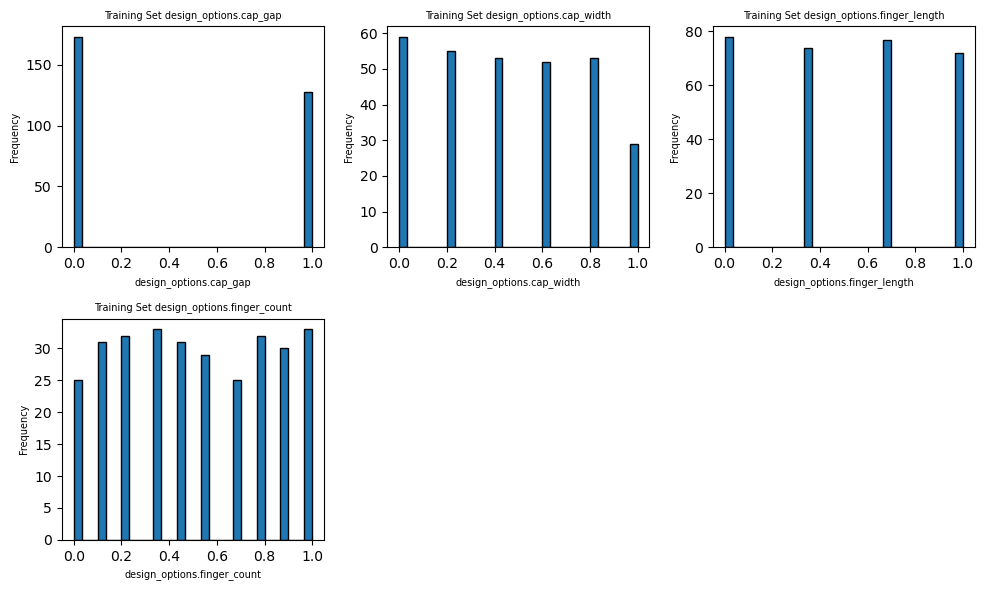

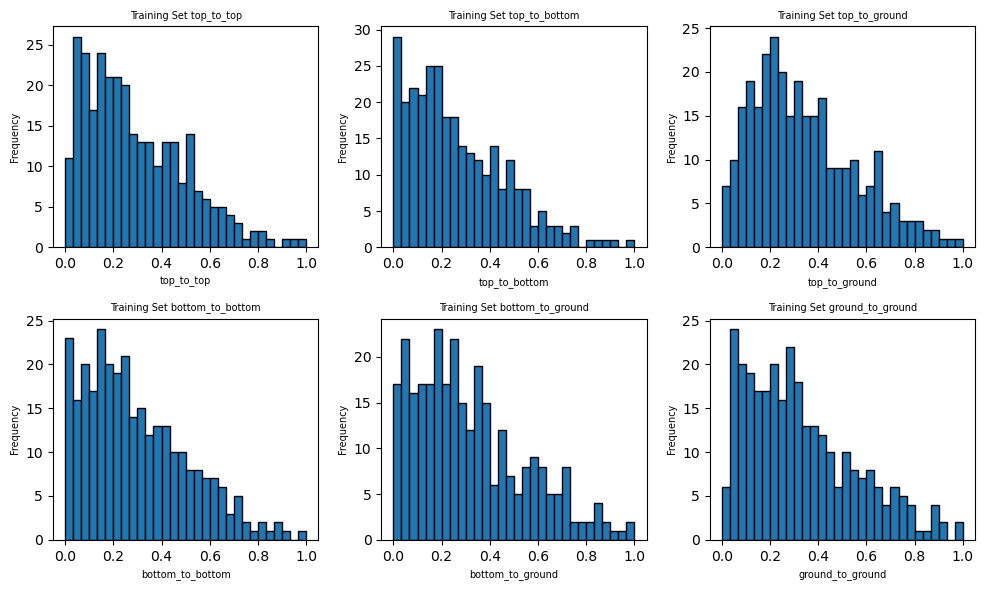

In [13]:
# Bin the input data (Qiskit Metal params) and look at distribution
num_cols = X_train.shape[1]
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i in range(num_cols):
    axes[i].hist(X_train[:, i], bins=30, edgecolor='black')
    label = qiskit_param_names[i] if i < len(qiskit_param_names) else f'col_{i}'
    axes[i].set_title(f'Training Set {label}', fontsize=7)
    axes[i].set_xlabel(label, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_training_set_input_distribution.pdf')
plt.show()

# Bin the output data (capacitance values) and look at distribution
num_cols = y_train.shape[1]
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i in range(num_cols):
    axes[i].hist(y_train[:, i], bins=30, edgecolor='black')
    label = cap_column_names[i] if i < len(cap_column_names) else f'col_{i}'
    axes[i].set_title(f'Training Set {label}', fontsize=7)
    axes[i].set_xlabel(label, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/model2_training_set_output_distribution.pdf')
plt.show()

In [14]:
steps_per_epoch = int(np.ceil(len(X_train) / TRAIN_BATCH_SIZE))
LR_DECAY_STEPS = steps_per_epoch * 20   # decay every ~20 epochs

## MLP

### Create model

Since all outputs are continuous capacitance values, this is a straightforward regression MLP.
No multi-head architecture needed — just a single linear output layer with MSE loss.

Reccomended to download a third party app like "Sleep control Center" or "Amphetamine" to prevent computer from sleeping during the many hour/day long training process

### Create Model by Hand

In [15]:
# just checkin to make sure everything looks good still, we want float32
print(X_train.dtype, X_train.shape)
print(y_train.dtype, y_train.shape)

import tensorflow as tf, platform
print("TF:", tf.__version__)
print("OS:", platform.platform())
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Built with ROCm:", tf.test.is_built_with_rocm())
print("GPUs:", tf.config.list_physical_devices("GPU"))

float32 (301, 4)
float32 (301, 6)
TF: 2.20.0
OS: Linux-6.3.12-200.fc38.x86_64-x86_64-with-glibc2.34
Built with CUDA: True
Built with ROCm: False
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Model shape string for file naming
    model_shape = f'model2_mlp_{X_train.shape[1]}_'
    model_shape += '_'.join(str(l) for l in NEURONS_PER_LAYER)
    model_shape += f'_{y_train.shape[1]}'

In [17]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Simple Sequential MLP — all outputs are continuous (capacitance values)
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],), name='input1'))
    
    for i, n in enumerate(NEURONS_PER_LAYER):
        model.add(Dense(n, name='fc{}'.format(i),
                        kernel_initializer='lecun_uniform',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        model.add(LeakyReLU(negative_slope=0.01, name='leaky_relu{}'.format(i)))
        model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name='dropout{}'.format(i)))
    
    # Single output layer: predict all capacitance values with linear activation
    model.add(Dense(y_train.shape[1], activation='linear', name='fc_output',
                    kernel_initializer='lecun_uniform'))

In [18]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=LR_INITIAL,  
        decay_steps=LR_DECAY_STEPS,        
        decay_rate=LR_DECAY_RATE,          
        staircase=LR_STAIRCASE             
    )
    
    model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_schedule),  
        loss=TRAIN_LOSS,                                         
        metrics=[TRAIN_LOSS]                                     
    )

In [19]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    !mkdir -p model
    best_model_file = 'model/{}_best_model.keras'.format(model_shape)
    last_model_file = 'model/{}_last_model.keras'.format(model_shape)

Enable training (`train_and_save`) to overwrite the model file.

In [20]:
train_and_save = True

We use Adam optimizer, minimize the loss specified in parameters, and early stop.

#### Training

In [21]:
from IPython.display import clear_output

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    class TrainingPlot(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs={}):
            self.losses = []
            self.val_losses = []
            self.logs = []
        
        def on_epoch_end(self, epoch, logs={}):
            self.logs.append(logs)
            self.losses.append(logs.get('loss'))
            self.val_losses.append(logs.get('val_loss'))
            
            if len(self.losses) > 1:
                clear_output(wait=True)
                N = np.arange(0, len(self.losses))
                plt.figure()
                plt.plot(N, self.losses, label='train_loss')
                plt.plot(N, self.val_losses, label='val_loss')
                plt.title('Training Loss [Epoch {}]'.format(epoch))
                plt.xlabel('Epoch #')
                plt.ylabel('Loss')
                plt.legend()
                plt.show()


class LearningRateMonitor(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.learning_rates = []

    def _current_lr(self, optimizer):
        lr = getattr(optimizer, 'lr', None) or getattr(optimizer, 'learning_rate', None)
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            return float(lr(optimizer.iterations).numpy())
        return float(tf.keras.backend.get_value(lr))

    def on_epoch_end(self, epoch, logs=None):
        try:
            lr_val = self._current_lr(self.model.optimizer)
        except Exception:
            lr_val = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.learning_rates.append(lr_val)

In [22]:
%%time

# Train the model
history = None  
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    if train_and_save: 
        early_stopping = EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE,
            verbose=1
        )
    
        plot_callback = TrainingPlot()
        lr_monitor = LearningRateMonitor()
        
        model_checkpoint = ModelCheckpoint(
            filepath=best_model_file,          
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=0
        )

        history = model.fit(
            np.asarray(X_train),  
            np.asarray(y_train),      
            epochs=400,                   
            batch_size=TRAIN_BATCH_SIZE,  
            validation_data=(np.asarray(X_val), np.asarray(y_val)),  
            callbacks=[early_stopping, model_checkpoint, plot_callback, lr_monitor],  
            verbose=1
        )
        
        model.save(last_model_file)

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 18.8 μs


Load the saved best model and use it from now on.

In [23]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    model = load_model(best_model_file, custom_objects={})

### Sweep total number of parameters to find the right range

In [24]:
if SWEEP_PARAM_NUM:
    def build_mlp(neurons_per_layer, input_dim, output_dim):
        model = Sequential()
        model.add(Input(shape=(input_dim,), name='input1'))
        for i, n in enumerate(neurons_per_layer):
            model.add(Dense(n, name=f'fc{i}', kernel_initializer='lecun_uniform',
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
            model.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name=f'dropout{i}'))
        model.add(Dense(output_dim, activation='linear', name='fc_output',
                        kernel_initializer='lecun_uniform'))
        return model
    
    def make_optimizer():
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=LR_INITIAL,
            decay_steps=LR_DECAY_STEPS,
            decay_rate=LR_DECAY_RATE,
            staircase=LR_STAIRCASE
        )
        return tf.optimizers.Adam(learning_rate=lr_schedule)
    
    def train_one_config(neurons_per_layer, seed=0):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        model = build_mlp(
            neurons_per_layer=neurons_per_layer,
            input_dim=X_train.shape[1],
            output_dim=y_train.shape[1],
        )
        model.compile(optimizer=make_optimizer(), loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
        early_stopping = EarlyStopping(
            monitor='val_loss', mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=0,
            restore_best_weights=True,
        )
        history = model.fit(
            np.asarray(X_train), np.asarray(y_train),
            validation_data=(np.asarray(X_val), np.asarray(y_val)),
            epochs=400, batch_size=TRAIN_BATCH_SIZE,
            callbacks=[early_stopping], verbose=0,
        )
        best_val = min(history.history['val_loss'])
        return model, history, best_val

In [25]:
if SWEEP_PARAM_NUM:
    from datetime import datetime
    run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_dir = 'sweep_outputs'
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, f'model2_sweep_results_{run_id}.csv')
    df.to_csv(csv_path, index=False)
    print('Saved:', csv_path)

In [26]:
if SWEEP_PARAM_NUM:
    plt.figure()
    plt.scatter(df['total_params'], df['best_val_loss'])
    plt.xscale('log')
    plt.xlabel('Total parameters (log scale)')
    plt.ylabel('Best val_loss')
    plt.title('Model 2: Best val_loss vs model size')
    plt.savefig('plots/model2_params_vs_loss.png')
    plt.show()

### Sweep amount of data used in training

In [27]:
if SWEEP_DATA_AMOUNT:
    FIXED_DEPTH = 1          
    FIXED_WIDTH = 1024        
    FIXED_NEURONS = [FIXED_WIDTH] * FIXED_DEPTH
    TRAIN_FRACTIONS = np.linspace(0.3, 1, 20)  
    SWEEP_SEEDS = [0, 1, 2, 3, 4]  

    def build_mlp(neurons_per_layer, input_dim, output_dim):
        model = Sequential()
        model.add(Input(shape=(input_dim,), name='input1'))
        for i, n in enumerate(neurons_per_layer):
            model.add(Dense(n, name=f'fc{i}', kernel_initializer='lecun_uniform',
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
            model.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name=f'dropout{i}'))
        model.add(Dense(output_dim, activation='linear', name='fc_output',
                        kernel_initializer='lecun_uniform'))
        return model

    def make_optimizer():
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=LR_INITIAL, decay_steps=LR_DECAY_STEPS,
            decay_rate=LR_DECAY_RATE, staircase=LR_STAIRCASE)
        return tf.optimizers.Adam(learning_rate=lr_schedule)

    def make_subset(X, y, frac, seed):
        assert 0 < frac <= 1.0
        n = len(X)
        m = max(1, int(np.floor(frac * n)))
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=m, replace=False)
        return X[idx], y[idx], m

### Keras Tuner to Find Best Hyperparameters

Run this if you want to use keras tuner to make the model rather than doing it by hand

In [28]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Input, Dropout
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    from keras_tuner import HyperModel, RandomSearch
    from tensorflow.keras.models import load_model

In [29]:
import gc
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    def build_hypermodel(hp):
        tf.keras.backend.clear_session()
        gc.collect()
        
        n_layers = hp.Int('n_layers', min_value=1, max_value=2, default=1)
        neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=32, max_value=1024, step=32) for i in range(n_layers)]
        dropout_rate = hp.Float('dropout_rate', 0.0, 0.45, step=0.05)
        l2_reg = hp.Float('l2_reg', 1e-5, 1e-2, sampling='LOG', default=1e-4)
        lr_initial = hp.Float('learning_rate', 1e-4, 3e-2, sampling='LOG', default=5e-4)
        use_batchnorm = hp.Boolean('use_batchnorm', default=True)
        
        # Simple Sequential model — all outputs are continuous
        model = Sequential()
        model.add(Input(shape=(X_train.shape[1],), name='input1'))
        for i, n_units in enumerate(neurons_per_layer):
            model.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                model.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            model.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            model.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        model.add(Dense(y_train.shape[1], name='output', kernel_initializer='he_normal'))
        model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                      loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
        return model

In [30]:
from keras_tuner import BayesianOptimization

if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner = BayesianOptimization(
        build_hypermodel,
        objective='val_loss',
        max_trials=KERAS_TUNER_TRIALS,
        executions_per_trial=2,
        directory=KERAS_DIR + '/hyper_tuning_model2_less_layers',
        project_name='model2_mlp_tuning_bayesian',
    )

I0000 00:00:1771951923.499578 1553480 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38660 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0


In [31]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    early_stopping = EarlyStopping(
        monitor='val_loss', mode='min',
        patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=max(10, TRAIN_EARLY_STOPPING_PATIENCE // 3),
        min_lr=1e-6, verbose=1
    )

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner.search(
        np.asarray(X_train), np.asarray(y_train),
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(y_val)),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
2                 |2                 |n_layers
960               |960               |neurons_0
0.3               |0.3               |dropout_rate
0.00083416        |0.00083416        |l2_reg
0.0003518         |0.0003518         |learning_rate
True              |True              |use_batchnorm

Epoch 1/400
1/4 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - loss: 2.6030 - mae: 0.9211

I0000 00:00:1771951931.147081 1554154 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 2.5745 - mae: 0.8939 - val_loss: 2.1955 - val_mae: 0.5175 - learning_rate: 3.5180e-04
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.5161 - mae: 0.8392 - val_loss: 2.1453 - val_mae: 0.4711 - learning_rate: 3.5180e-04
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.4818 - mae: 0.8087 - val_loss: 2.1276 - val_mae: 0.4571 - learning_rate: 3.5180e-04
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.4466 - mae: 0.7772 - val_loss: 2.1154 - val_mae: 0.4486 - learning_rate: 3.5180e-04
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.4312 - mae: 0.7655 - val_loss: 2.1034 - val_mae: 0.4403 - learning_rate: 3.5180e-04
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.3941 - mae: 0.7322 - val_loss: 2.0777 - val_mae: 0.4184 - learning_rate: 3.5180e-04
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.3761 - mae: 0.7180 - val_loss: 2.0508 - val_mae: 0.3954 - learning_rate: 3.5180e-04
Epoch

In [ ]:
encoding = 'model2_surrogate'
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    os.makedirs('model', exist_ok=True)
    best_model_file = f'model/best_keras_model_{encoding}.keras'
    best_model = tuner.get_best_models(1)[0]
    best_model.save(best_model_file)
    tf.keras.backend.clear_session()
    gc.collect()
    with tf.device('/CPU:0'):
        loaded_model = load_model(best_model_file, compile=False)

### View the model

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    best_model.summary()

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('\n---- Model Summary ----')
    model.summary()

### Evaluation

Plot training history.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Visualize gradients for best model

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    class GradientNormLogger(tf.keras.callbacks.Callback):
        def __init__(self, x_probe, y_probe, layer_name_prefixes=('fc', 'output'),
                     log_every=1, max_items_per_prefix=10, verbose=1):
            super().__init__()
            self.x_probe = tf.convert_to_tensor(x_probe)
            self.y_probe = tf.convert_to_tensor(y_probe)
            self.layer_name_prefixes = tuple(layer_name_prefixes)
            self.log_every = int(log_every)
            self.max_items_per_prefix = int(max_items_per_prefix)
            self.verbose = int(verbose)
            self.records = []

        def _want_layer(self, var_name):
            return any(var_name.startswith(pfx) for pfx in self.layer_name_prefixes)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            if (epoch + 1) % self.log_every != 0:
                return
            with tf.GradientTape() as tape:
                y_pred = self.model(self.x_probe, training=True)
                loss = self.model.compiled_loss(self.y_probe, y_pred)
            grads = tape.gradient(loss, self.model.trainable_weights)
            rec = {'epoch': int(epoch + 1), 'probe_loss': float(loss.numpy())}
            per_layer = {}
            for w, g in zip(self.model.trainable_weights, grads):
                if g is None:
                    continue
                wname = w.name.split(':')[0]
                if not self._want_layer(wname):
                    continue
                g_norm = tf.linalg.global_norm([g]).numpy().item()
                rec[f'grad_norm__{wname}'] = float(g_norm)
                layer_key = wname.split('/')[0]
                per_layer.setdefault(layer_key, []).append(g_norm)
            for layer_key, norms in per_layer.items():
                rec[f'grad_mean__{layer_key}'] = float(np.mean(norms))
                rec[f'grad_max__{layer_key}'] = float(np.max(norms))
            g_all = [g for g in grads if g is not None]
            rec['grad_global_norm'] = float(tf.linalg.global_norm(g_all).numpy().item()) if g_all else float('nan')
            self.records.append(rec)
            for k in list(rec.keys()):
                if k != 'epoch':
                    logs[k] = rec[k]
            if self.verbose:
                msg = [f"[Grad] epoch={rec['epoch']} probe_loss={rec['probe_loss']:.6g} global={rec['grad_global_norm']:.3g}"]
                for lk in ('fc0', 'output'):
                    if f'grad_mean__{lk}' in rec:
                        msg.append(f"{lk}:mean={rec[f'grad_mean__{lk}']:.3g} max={rec[f'grad_max__{lk}']:.3g}")
                print(' | '.join(msg))

        def to_csv(self, path):
            import csv
            if not self.records:
                return
            keys = sorted({k for r in self.records for k in r.keys()})
            with open(path, 'w', newline='') as f:
                w = csv.DictWriter(f, fieldnames=keys)
                w.writeheader()
                w.writerows(self.records)

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    probe_n = min(256, len(X_train))
    x_probe = np.asarray(X_train[:probe_n])
    y_probe = np.asarray(y_train[:probe_n])
    
    grad_logger = GradientNormLogger(
        x_probe=x_probe, y_probe=y_probe,
        layer_name_prefixes=('fc0', 'output'),
        log_every=1, verbose=1
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    
    history = model.fit(
        np.asarray(X_train), np.asarray(y_train),
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(y_val)),
        callbacks=[early_stopping, lr_monitor, grad_logger], verbose=1
    )
    grad_logger.to_csv(f'plots/{encoding}_gradients.csv')
    del model
    tf.keras.backend.clear_session()
    gc.collect()

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    dfg = pd.DataFrame(grad_logger.records)
    plt.figure()
    plt.plot(dfg['epoch'], dfg['grad_global_norm'])
    plt.yscale('log')
    plt.title('Gradient tracking for a single batch across epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Gradient magnitude (log scale)')
    plt.tight_layout()
    plt.savefig(f'plots/{encoding}_grad_global_norm.pdf')
    plt.show()
    
    for lk in ['fc0', 'output']:
        col = f'grad_mean__{lk}'
        if col in dfg.columns:
            plt.figure()
            plt.plot(dfg['epoch'], dfg[col])
            plt.yscale('log')
            plt.title(f'Gradient Mean Norm: {lk} (probe batch)')
            plt.xlabel('Epoch')
            plt.ylabel('Mean grad norm (log scale)')
            plt.tight_layout()
            plt.savefig(f'plots/{encoding}_grad_mean_{lk}.pdf')
            plt.show()

### Look at best model

In [ ]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and not VISUALIZE_GRADIENTS:
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    
    history = model.fit(
        np.asarray(X_train), np.asarray(y_train),
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(y_val)),
        callbacks=[early_stopping, lr_monitor], verbose=1
    )
    del model
    tf.keras.backend.clear_session()
    gc.collect()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model 2 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.tight_layout()
plt.savefig(f'plots/model2_history.pdf')
plt.show()

plt.plot(lr_monitor.learning_rates)
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.tight_layout()
plt.savefig(f'plots/model2_learning_rate.pdf')
plt.show()

### Test set evaluation

In [ ]:
# Evaluate on test set
tf.keras.backend.clear_session()
gc.collect()

def get_loss(eval_out):
    if isinstance(eval_out, dict):
        return float(eval_out.get('loss', list(eval_out.values())[0]))
    if isinstance(eval_out, (list, tuple, np.ndarray)):
        return float(eval_out[0])
    return float(eval_out)

def mlp_signature(m, prefix='model2_mlp'):
    in_shape = m.input_shape
    if isinstance(in_shape, list):
        in_shape = in_shape[0]
    dims = [d for d in in_shape[1:] if d is not None]
    input_size = int(np.prod(dims)) if dims else 'None'
    dense_units = [l.units for l in m.layers if isinstance(l, Dense)]
    parts = [prefix, str(input_size)] + [str(u) for u in dense_units]
    return '_'.join(parts)

model = load_model(best_model_file, compile=False)
model.compile(optimizer='adam', loss=TRAIN_LOSS)
test_loss_result = get_loss(model.evaluate(np.asarray(X_test), np.asarray(y_test)))
test_loss_result = get_loss(test_loss_result)

model_shape = mlp_signature(model)
print(f'Model 2 test loss ({TRAIN_LOSS}): {test_loss_result}')

results_df = pd.DataFrame([{
    'Model': 'Model Set 2 (Ansys Surrogate)',
    'Train Loss Metric': TRAIN_LOSS,
    'Test Loss': test_loss_result,
}])
print(results_df.to_string(index=False))
results_df.to_csv('model2_test_loss_results.csv', index=False)

## Compare predictions vs. test set

In [ ]:
import csv
csv_data = [[
    DATA_AUGMENTATION,
    model_shape,
    'Model2_QiskitToCapacitance',
    test_loss_result,
    TRAIN_LOSS,
    TRAIN_DROPOUT_RATE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_BATCH_SIZE,
    '0.15/0.15',
    LR_INITIAL,
    LR_DECAY_STEPS,
    LR_DECAY_RATE,
    LR_STAIRCASE
]]

csv_file = 'model2_history_losses.csv'

if not os.path.exists(csv_file):
    with open(csv_file, 'w') as file:
        file.write('data_augmentation,model_shape,model_type,test_loss,train_loss,train_dropout_rate,'
                   'train_early_stop_patience,train_batch_size,train_val_split,lr_initial,'
                   'lr_decay_step,lr_decay_rate,lr_stair_case\n')

with open(csv_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(csv_data)

df = pd.read_csv(csv_file)
styled_df = df.style.apply(lambda s: ['color: red' if v else '' for v in s], subset=['test_loss'])
display(styled_df)

In [ ]:
# Predict on test set
tf.keras.backend.clear_session()
gc.collect()

with tf.device('/CPU:0'):
    chosen_model = load_model(best_model_file, compile=False)
    y_pred = chosen_model.predict(np.asarray(X_test), verbose=0)

In [ ]:
# Look at specific cases to see how the model predicts capacitance values

X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)
y_pred     = np.asarray(y_pred)

n_samples, n_params = y_test_cur.shape
n_samples_to_show = 3  # change this if you want to see more

sq_errors  = (y_test_cur - y_pred) ** 2
abs_errors = np.abs(y_test_cur - y_pred)

rows = []
for i in range(n_samples_to_show):
    for j in range(n_params):
        label = cap_column_names[j] if j < len(cap_column_names) else f'cap_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref': y_test_cur[i, j],
            'pred': y_pred[i, j],
            'abs_error': abs_errors[i, j],
            'sq_error': sq_errors[i, j],
        })

df_pred = pd.DataFrame(rows)

out_csv = Path(f'model2_predictions_and_errors_scaled.csv')
df_pred.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

for i in range(n_samples_to_show):
    sub = df_pred[df_pred['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    # Show the input Qiskit params for this sample
    input_str = ', '.join(f'{qiskit_param_names[k] if k < len(qiskit_param_names) else f"col_{k}"}={X_test_cur[i,k]:.6g}' for k in range(X_test_cur.shape[1]))
    print(f'— Sample {i} — Inputs: {input_str}')
    print(sub.to_string(index=False))
    print()

print('Global error stats (scaled):')
print('  min abs_error:', float(abs_errors.min()))
print('  median abs_error:', float(np.median(abs_errors)))
print('  max abs_error:', float(abs_errors.max()))

### Unscaled test vs predictions

In [ ]:
# Unscale everything and look at errors in real units
# For Model 2, inputs are Qiskit params (old Y) and outputs are capacitance (old X)
# So we use the Y scalers for our inputs and X scalers for our outputs

# Load column names
with open('X_names', 'r') as f:
    cap_names = f.read().splitlines()  # capacitance column names (our outputs)

qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()  # our inputs

# Unscale inputs (Qiskit params) using the OLD Y scalers (linear encoding)
X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        param_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_y_linear_{param_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale outputs (capacitance) using the OLD X scalers
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(y_test_unscaled.shape[0]):
    for j in range(y_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_X_linear_{cap_name}.save')
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

# Unscale predictions (capacitance) using same X scalers
y_pred_unscaled = np.asarray(y_pred.copy())
for i in range(y_pred_unscaled.shape[0]):
    for j in range(y_pred_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_X_linear_{cap_name}.save')
        y_pred_unscaled[i, j] = scaler.inverse_transform([[y_pred_unscaled[i, j]]])[0][0]

n_samples_to_show = 3

sq_errors_unscaled  = (y_test_unscaled - y_pred_unscaled) ** 2
abs_errors_unscaled = np.abs(y_test_unscaled - y_pred_unscaled)

rows_unscaled = []
for i in range(n_samples_to_show):
    for j in range(y_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': cap_name,
            'ref_unscaled': y_test_unscaled[i, j],
            'pred_unscaled': y_pred_unscaled[i, j],
            'abs_error_unscaled': abs_errors_unscaled[i, j],
            'sq_error_unscaled': sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

out_csv_unscaled = Path('model2_predictions_and_errors_unscaled.csv')
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

for i in range(n_samples_to_show):
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    input_str = ', '.join(f'{qiskit_names[k] if k < len(qiskit_names) else f"col_{k}"}={X_test_unscaled[i,k]:.6g}' for k in range(X_test_unscaled.shape[1]))
    print(f'— Sample {i} (Unscaled) — Inputs: {input_str}')
    print(sub.to_string(index=False))
    print()

print('Global unscaled error stats:')
print('  min abs_error:', float(abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(abs_errors_unscaled)))
print('  max abs_error:', float(abs_errors_unscaled.max()))